# 04 - Validation + TTA + Calibration (Platt) — version corrigée

Ce notebook recharge le meilleur checkpoint SmallCNN, reconstruit le même split validation que dans le notebook d'entraînement, puis apprend une calibration Platt sur les probabilités TTA de la validation uniquement.

## Objectifs
- recharger le checkpoint final du modèle ;
- reconstruire le split validation avec la même seed ;
- calculer les probabilités TTA sur la validation ;
- apprendre une calibration Platt scaling sur cette validation ;
- comparer les probabilités brutes et calibrées ;
- sauvegarder le calibrateur dans `artifacts/calibrator.pkl`.


In [16]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print("PROJECT_ROOT =", PROJECT_ROOT)
print("SRC_DIR =", SRC_DIR)


PROJECT_ROOT = /home/alouiyaz/projects/PINKCC/Brain_tumor_MRI_classification
SRC_DIR = /home/alouiyaz/projects/PINKCC/Brain_tumor_MRI_classification/src


In [17]:
import json
from collections import Counter

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
)

from brain_tumor_mri.data.dataset import BrainMRIDataset
from brain_tumor_mri.data.split import make_train_val_split, describe_split
from brain_tumor_mri.data.transforms import get_tta_transforms
from brain_tumor_mri.models.builder import build_model
from brain_tumor_mri.inference.tta import predict_probabilities_tta
from brain_tumor_mri.evaluation.metrics import compute_auprc
from brain_tumor_mri.utils import get_device, set_seed


## Configuration

Les paramètres `seed` et `val_size` doivent être identiques à ceux du notebook 03 pour reconstruire exactement le même jeu de validation.


In [18]:
CONFIG = {
    "seed": 42,
    "model_name": "cnn_small",
    "num_classes": 2,
    "pretrained": False,
    "img_size": 224,
    "val_size": 0.20,
    "checkpoint_name": "best_smallcnn_baseline.pt",
    "calibrator_name": "calibrator.pkl",
    "threshold_after_calibration": 0.5,
}

CONFIG


{'seed': 42,
 'model_name': 'cnn_small',
 'num_classes': 2,
 'pretrained': False,
 'img_size': 224,
 'val_size': 0.2,
 'checkpoint_name': 'best_smallcnn_baseline.pt',
 'calibrator_name': 'calibrator.pkl',
 'threshold_after_calibration': 0.5}

## Chemins et device


In [19]:
set_seed(CONFIG["seed"])
device = get_device()

TRAIN_ROOT = PROJECT_ROOT / "data" / "raw" / "brain_mri" / "Training"
CHECKPOINT_PATH = PROJECT_ROOT / "artifacts" / "checkpoints" / CONFIG["checkpoint_name"]
CALIBRATOR_PATH = PROJECT_ROOT / "artifacts" / CONFIG["calibrator_name"]

print("Device:", device)
print("TRAIN_ROOT =", TRAIN_ROOT)
print("CHECKPOINT_PATH =", CHECKPOINT_PATH)
print("CALIBRATOR_PATH =", CALIBRATOR_PATH)
print("Checkpoint exists:", CHECKPOINT_PATH.exists())

Device: cpu
TRAIN_ROOT = /home/alouiyaz/projects/PINKCC/Brain_tumor_MRI_classification/data/raw/brain_mri/Training
CHECKPOINT_PATH = /home/alouiyaz/projects/PINKCC/Brain_tumor_MRI_classification/artifacts/checkpoints/best_smallcnn_baseline.pt
CALIBRATOR_PATH = /home/alouiyaz/projects/PINKCC/Brain_tumor_MRI_classification/artifacts/calibrator.pkl
Checkpoint exists: True


## Reconstruction du split validation

Ici, on ne calibre pas sur tout `Training`. On reconstruit le vrai split validation et on utilise uniquement ce jeu pour la calibration.


In [20]:
full_dataset_labels = BrainMRIDataset(TRAIN_ROOT, transform=None)
labels = full_dataset_labels.get_labels()

print("Total images in Training:", len(labels))
print("Global distribution:", Counter(labels))

train_idx, val_idx = make_train_val_split(
    labels=labels,
    val_size=CONFIG["val_size"],
    random_state=CONFIG["seed"],
)

describe_split([labels[i] for i in train_idx], name="train")
describe_split([labels[i] for i in val_idx], name="val")

print("Validation size:", len(val_idx))


Total images in Training: 2870
Global distribution: Counter({1: 2475, 0: 395})
train size = 2296
train distribution = Counter({1: 1980, 0: 316})
val size = 574
val distribution = Counter({1: 495, 0: 79})
Validation size: 574


## Charger le modèle final


In [21]:
device = get_device()

model = build_model(
    model_name=CONFIG["model_name"],
    num_classes=CONFIG["num_classes"],
    pretrained=CONFIG["pretrained"],
    img_size=CONFIG["img_size"],
).to(device)

ckpt = torch.load(CHECKPOINT_PATH, map_location=device)

if isinstance(ckpt, dict) and "model_state_dict" in ckpt:
    model.load_state_dict(ckpt["model_state_dict"])
else:
    model.load_state_dict(ckpt)

model.eval()
print("Checkpoint loaded successfully.")


Checkpoint loaded successfully.


## Construire le vrai dataset de validation pour la TTA

On part du dossier `Training`, puis on ne garde que les échantillons de validation.


In [22]:
val_dataset = BrainMRIDataset(TRAIN_ROOT, transform=None)
val_dataset.samples = [val_dataset.samples[i] for i in val_idx]

print("Validation dataset for calibration:", len(val_dataset))
print("Validation distribution:", Counter(val_dataset.get_labels()))


Validation dataset for calibration: 574
Validation distribution: Counter({1: 495, 0: 79})


## Probabilités TTA sur la validation


In [23]:
tta_tfms = get_tta_transforms(img_size=CONFIG["img_size"])

y_true_val, y_probs_val_raw = predict_probabilities_tta(
    model=model,
    dataset=val_dataset,
    device=device,
    tta_transforms=tta_tfms,
)

y_true_val = np.array(y_true_val)
y_probs_val_raw = np.array(y_probs_val_raw)

print("Validation PRAUC (raw):", compute_auprc(y_true_val, y_probs_val_raw))
print("Raw probabilities range:", float(y_probs_val_raw.min()), "->", float(y_probs_val_raw.max()))

Validation PRAUC (raw): 0.997755008902528
Raw probabilities range: 5.3777825087308884e-05 -> 1.0


## Calibration Platt scaling

On ajuste une régression logistique sur les probabilités TTA de validation.


In [24]:
calibrator = LogisticRegression()
calibrator.fit(y_probs_val_raw.reshape(-1, 1), y_true_val)

y_probs_val_cal = calibrator.predict_proba(y_probs_val_raw.reshape(-1, 1))[:, 1]

print("Validation PRAUC (calibrated):", compute_auprc(y_true_val, y_probs_val_cal))
print("Calibrated probabilities range:", float(y_probs_val_cal.min()), "->", float(y_probs_val_cal.max()))


Validation PRAUC (calibrated): 0.997755008902528
Calibrated probabilities range: 0.13241953958586478 -> 0.9764893550027693


## Comparaison brute vs calibrée sur validation


In [25]:
THRESHOLD = CONFIG["threshold_after_calibration"]

y_pred_raw_05 = (y_probs_val_raw >= 0.5).astype(int)
y_pred_cal_05 = (y_probs_val_cal >= THRESHOLD).astype(int)

def summarize(y_true, y_pred, y_probs, setup):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return {
        "setup": setup,
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "prauc": float(compute_auprc(y_true, y_probs)),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
    }

summary_raw = summarize(y_true_val, y_pred_raw_05, y_probs_val_raw, "Raw TTA + threshold 0.5")
summary_cal = summarize(y_true_val, y_pred_cal_05, y_probs_val_cal, "Calibrated TTA + threshold 0.5")

pd.DataFrame([summary_raw, summary_cal])

,setup,accuracy,precision,recall,f1,prauc,TN,FP,FN,TP
0,Raw TTA + threshold 0.5,0.961672,0.985626,0.969697,0.977597,0.997755,72,7,15,480
1,Calibrated TTA + threshold 0.5,0.956446,0.971888,0.977778,0.974824,0.997755,65,14,11,484


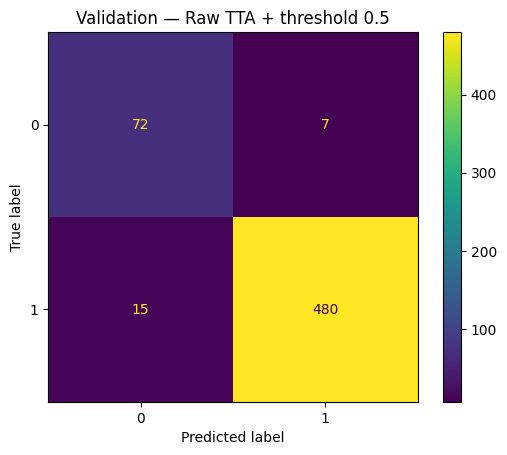

              precision    recall  f1-score   support

           0     0.8276    0.9114    0.8675        79
           1     0.9856    0.9697    0.9776       495

    accuracy                         0.9617       574
   macro avg     0.9066    0.9405    0.9225       574
weighted avg     0.9639    0.9617    0.9624       574



In [26]:
cm_raw = confusion_matrix(y_true_val, y_pred_raw_05)
ConfusionMatrixDisplay(cm_raw).plot()
plt.title("Validation — Raw TTA + threshold 0.5")
plt.show()

print(classification_report(y_true_val, y_pred_raw_05, digits=4))

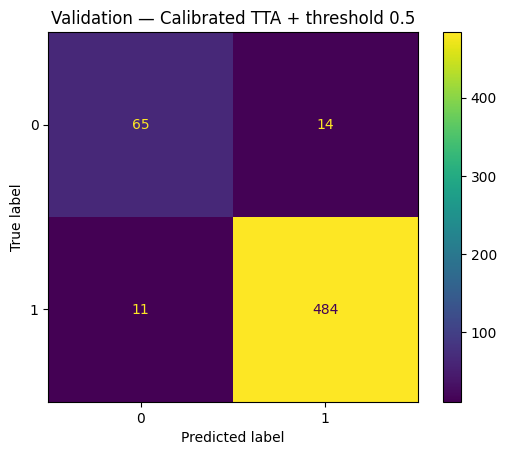

              precision    recall  f1-score   support

           0     0.8553    0.8228    0.8387        79
           1     0.9719    0.9778    0.9748       495

    accuracy                         0.9564       574
   macro avg     0.9136    0.9003    0.9068       574
weighted avg     0.9558    0.9564    0.9561       574



In [27]:
cm_cal = confusion_matrix(y_true_val, y_pred_cal_05)
ConfusionMatrixDisplay(cm_cal).plot()
plt.title("Validation — Calibrated TTA + threshold 0.5")
plt.show()

print(classification_report(y_true_val, y_pred_cal_05, digits=4))


## Sauvegarder le calibrateur


In [28]:
CALIBRATOR_PATH.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(calibrator, CALIBRATOR_PATH)
print("Calibrator saved to:", CALIBRATOR_PATH)

Calibrator saved to: /home/alouiyaz/projects/PINKCC/Brain_tumor_MRI_classification/artifacts/calibrator.pkl


## Résumé JSON


In [29]:
summary = {
    "checkpoint_path": str(CHECKPOINT_PATH),
    "calibrator_path": str(CALIBRATOR_PATH),
    "validation_size": int(len(val_dataset)),
    "raw_summary": summary_raw,
    "calibrated_summary": summary_cal,
}

print(json.dumps(summary, indent=2))

{
  "checkpoint_path": "/home/alouiyaz/projects/PINKCC/Brain_tumor_MRI_classification/artifacts/checkpoints/best_smallcnn_baseline.pt",
  "calibrator_path": "/home/alouiyaz/projects/PINKCC/Brain_tumor_MRI_classification/artifacts/calibrator.pkl",
  "validation_size": 574,
  "raw_summary": {
    "setup": "Raw TTA + threshold 0.5",
    "accuracy": 0.9616724738675958,
    "precision": 0.9856262833675564,
    "recall": 0.9696969696969697,
    "f1": 0.9775967413441955,
    "prauc": 0.997755008902528,
    "TN": 72,
    "FP": 7,
    "FN": 15,
    "TP": 480
  },
  "calibrated_summary": {
    "setup": "Calibrated TTA + threshold 0.5",
    "accuracy": 0.9564459930313589,
    "precision": 0.9718875502008032,
    "recall": 0.9777777777777777,
    "f1": 0.9748237663645518,
    "prauc": 0.997755008902528,
    "TN": 65,
    "FP": 14,
    "FN": 11,
    "TP": 484
  }
}
